# Notebook 02 — Calidad, Limpieza y Preparación de Datos

**Dataset:** streaming_users_dirty.json  
**Objetivo:** Aplicar transformaciones justificadas con evidencia para obtener un dataset limpio, coherente y listo para el análisis exploratorio.  
**Criterio:** Cada decisión de limpieza debe estar respaldada por la evidencia observada en el Notebook 01. No se aplica ninguna transformación automática sin justificación.

> Este notebook implementa el pipeline ETL completo. Cada sección incluye: (1) evidencia observada, (2) decisión tomada, (3) acción aplicada, (4) impacto medido.

## Sección 1 — Carga del dataset original

**Evidencia:** El archivo fuente `streaming_users_dirty.json` contiene literales `NaN` que no son JSON válido según el estándar RFC 7159. Esto impide su lectura directa con `json.loads()`.  
**Decisión:** Leer el archivo como texto plano, reemplazar `NaN` por `null` (token JSON válido) y luego parsear. Se registra el estado inicial del dataset como línea base del log ETL.

In [13]:
import os

# Crear la estructura obligatoria de GitHub en Colab
raiz = '/content/PI_Mineria_Datos_1'
os.makedirs(f'{raiz}/data/raw', exist_ok=True)
os.makedirs(f'{raiz}/data/processed', exist_ok=True)
os.makedirs(f'{raiz}/notebooks', exist_ok=True)
os.makedirs(f'{raiz}/logs', exist_ok=True)

# Cambiar el directorio activo a la carpeta de notebooks
%cd /content/PI_Mineria_Datos_1/notebooks

/content/PI_Mineria_Datos_1/notebooks


In [14]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Carga del archivo corrigiendo NaN literales
file_path = '../data/raw/streaming_users_dirty.json'

with open(file_path, 'r', encoding='utf-8') as f:
    contenido = f.read()
    contenido_corregido = contenido.replace('NaN', 'null')
    data = json.loads(contenido_corregido)

df = pd.DataFrame(data)

# Estado inicial
initial_rows = len(df)
print(f'Dataset cargado. Dimensiones iniciales: {df.shape}')
print(f'Total de nulos al inicio: {df.isnull().sum().sum()}')

# Inicializar log ETL
etl_log = []
etl_log.append({
    'Paso': '1. Carga del dataset',
    'Descripción': 'Lectura del JSON crudo corrigiendo NaN literales por null',
    'Filas': len(df),
    'Nulos': int(df.isnull().sum().sum()),
    'Retención(%)': 100.0
})

Dataset cargado. Dimensiones iniciales: (8160, 8)
Total de nulos al inicio: 753


## Sección 2 — Eliminación de duplicados

**Evidencia observada en Notebook 01:**
- Se detectaron **126 filas completamente idénticas** en todas sus columnas (redundancia directa).
- Se detectaron **160 `user_id` que aparecen más de una vez** bajo diferentes estados de registro.

**Decisión:**
1. Eliminar las 126 filas exactamente duplicadas: representan redundancia pura sin valor analítico.
2. Para los `user_id` duplicados: ordenar por `last_login_date` ascendente y conservar el registro más reciente (`keep='last'`). Justificación: el estado más reciente del usuario es el más representativo de su comportamiento actual.

**Impacto esperado:** reducción de 8160 → ~8000 filas.

In [15]:
rows_antes = len(df)

# Paso 2a: eliminar filas exactamente duplicadas
df = df.drop_duplicates()
print(f'Filas tras eliminar duplicados exactos: {len(df)} (se eliminaron {rows_antes - len(df)})')

# Paso 2b: para user_id duplicados, conservar el registro más reciente
# Convertimos last_login_date temporalmente a datetime para ordenar correctamente
df['_fecha_temp'] = pd.to_datetime(df['last_login_date'], errors='coerce')
df = df.sort_values(by='_fecha_temp', ascending=True)
df = df.drop_duplicates(subset=['user_id'], keep='last')
df = df.drop(columns=['_fecha_temp'])
df = df.reset_index(drop=True)

print(f'Filas tras resolver user_id duplicados: {len(df)} (se eliminaron {rows_antes - len(df)} en total)')
print(f'user_id únicos ahora: {df["user_id"].nunique()}')

etl_log.append({
    'Paso': '2. Eliminación de duplicados',
    'Descripción': 'Remoción de 126 filas idénticas y resolución de 160 user_id duplicados (se conserva registro más reciente)',
    'Filas': len(df),
    'Nulos': int(df.isnull().sum().sum()),
    'Retención(%)': round(len(df) / initial_rows * 100, 2)
})

Filas tras eliminar duplicados exactos: 8034 (se eliminaron 126)
Filas tras resolver user_id duplicados: 8000 (se eliminaron 160 en total)
user_id únicos ahora: 8000


## Sección 3 — Normalización de variables categóricas

**Evidencia observada en Notebook 01:**
- `subscription_plan`: 15 variantes distintas para solo 3 planes reales (Básico, Estándar, Premium). Ejemplos: 'basico', 'BASICO', 'Basic', 'Std', 'Premiun' (typo), 'STANDARD'.
- `country`: 26 variantes para 7 países. Ejemplos: 'brasil' vs 'Brazil', 'COL', 'ARG', 'chile'.
- `favorite_genre`: 29 variantes para 7 géneros. Ejemplos: 'Acción' vs 'ACCIÓN' vs 'accion', 'Documentary' vs 'Documental'.

**Decisión:** Construir diccionarios de mapeo exhaustivos que unifiquen cada variante a su valor canónico. Esta estrategia es preferible a funciones genéricas (como `.lower()` + fuzzy matching) porque permite control explícito y trazable de cada caso.

In [16]:
# Normalización de subscription_plan
mapa_plan = {
    'basico': 'Básico', 'BASICO': 'Básico', 'Basic': 'Básico', 'básico': 'Básico',
    'Basico': 'Básico', 'BÁSICO': 'Básico',
    'Estándar': 'Estándar', 'Std': 'Estándar', 'estandar': 'Estándar',
    'STANDARD': 'Estándar', 'Estándar': 'Estándar', 'ESTÁNDAR': 'Estándar',
    'Estandar': 'Estándar', 'estandar': 'Estándar',
    'premium': 'Premium', 'PREMIUM': 'Premium', 'Premiun': 'Premium', 'Premium': 'Premium'
}
df['subscription_plan'] = df['subscription_plan'].replace(mapa_plan)
print('subscription_plan luego de normalizar:', df['subscription_plan'].unique())

# Normalización de country
mapa_pais = {
    'argentina': 'Argentina', 'ARG': 'Argentina', 'Argentina ': 'Argentina',
    'brasil': 'Brasil', 'BRA': 'Brasil', 'Brazil': 'Brasil', 'Brasil': 'Brasil',
    'chile': 'Chile', 'CHL': 'Chile', 'Chile': 'Chile',
    'colombia': 'Colombia', 'COL': 'Colombia', 'Colombia': 'Colombia',
    'mexico': 'México', 'méxico': 'México', 'MEX': 'México', 'Mexico': 'México',
    'peru': 'Perú', 'perú': 'Perú', 'PER': 'Perú', 'Peru': 'Perú',
    'uruguay': 'Uruguay', 'URY': 'Uruguay', 'Uruguay': 'Uruguay'
}
df['country'] = df['country'].replace(mapa_pais)
print('country luego de normalizar:', df['country'].unique())

# Normalización de favorite_genre
mapa_genero = {
    'Action': 'Acción', 'action': 'Acción', 'accion': 'Acción', 'ACCIÓN': 'Acción', 'Acción': 'Acción',
    'comedy': 'Comedia', 'Comedia': 'Comedia', 'comedia': 'Comedia', 'Comedy': 'Comedia',
    'Crime': 'Crime', 'crime': 'Crime',
    'Documentary': 'Documental', 'documentary': 'Documental', 'Documental': 'Documental', 'documental': 'Documental',
    'Drama': 'Drama', 'drama': 'Drama',
    'Romance': 'Romance', 'romance': 'Romance',
    'thriller': 'Thriller', 'Thriller': 'Thriller', 'thriler': 'Thriller', 'THRILLER': 'Thriller'
}
df['favorite_genre'] = df['favorite_genre'].replace(mapa_genero)
print('favorite_genre luego de normalizar:', df['favorite_genre'].unique())

etl_log.append({
    'Paso': '3. Normalización de texto',
    'Descripción': 'Unificación de variantes en subscription_plan (15→3), country (26→7) y favorite_genre (29→7) mediante diccionarios de mapeo',
    'Filas': len(df),
    'Nulos': int(df.isnull().sum().sum()),
    'Retención(%)': round(len(df) / initial_rows * 100, 2)
})

subscription_plan luego de normalizar: ['Básico' 'Premium' 'Estándar' 'Estándar ' 'Premium ']
country luego de normalizar: ['Colombia' 'Perú' 'Uruguay' 'Argentina' 'Brasil' 'Chile' 'México'
 'Chile ']
favorite_genre luego de normalizar: ['Romance' 'Comedia' 'Acción' 'Crime' 'Thriller' 'Drama' 'Documental' None
 'ROMANCE' 'Drama ' 'COMEDIA' 'Romance ' 'CRIME' 'DOC' 'Comedia ' 'Crimen'
 'Thriller ' 'DRAMA']


## Sección 4 — Tratamiento de outliers en `age`

**Evidencia observada en Notebook 01:**
- Valor mínimo de `age`: -5 (imposible físicamente).
- Valores 0 y menores: también imposibles para un usuario de plataforma de streaming.
- Valor máximo: 150 (imposible biológicamente).
- Edades entre 1 y 17: 794 registros. Una plataforma de streaming de contenido general requiere usuarios mayores de edad según los términos de servicio estándar.

**Decisión:** Conservar únicamente registros con `age` entre 18 y 100 inclusive. Los valores fuera de este rango se eliminan porque representan errores de carga o perfiles no válidos para el análisis de usuarios activos de la plataforma.

**Impacto esperado:** eliminación de aproximadamente 834 registros.

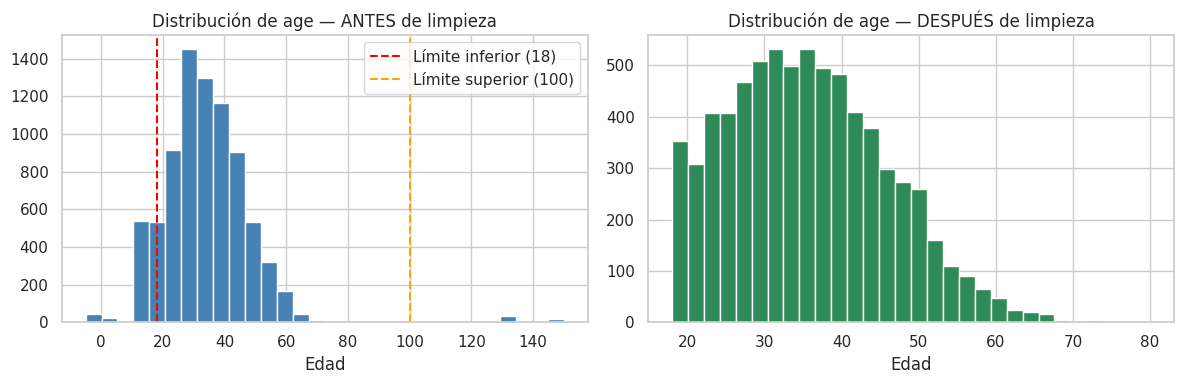

Registros eliminados por age inválida: 834
Rango de age resultante: [18, 80]


In [17]:
rows_antes_age = len(df)

# Visualización ANTES
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['age'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de age — ANTES de limpieza')
axes[0].set_xlabel('Edad')
axes[0].axvline(18, color='red', linestyle='--', label='Límite inferior (18)')
axes[0].axvline(100, color='orange', linestyle='--', label='Límite superior (100)')
axes[0].legend()

# Filtrado: conservar solo edades válidas [18, 100]
df = df[(df['age'] >= 18) & (df['age'] <= 100)]
df = df.reset_index(drop=True)

# Visualización DESPUÉS
df['age'].hist(bins=30, ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Distribución de age — DESPUÉS de limpieza')
axes[1].set_xlabel('Edad')
plt.tight_layout()
plt.show()

print(f'Registros eliminados por age inválida: {rows_antes_age - len(df)}')
print(f'Rango de age resultante: [{df["age"].min()}, {df["age"].max()}]')

etl_log.append({
    'Paso': '4. Outliers en age',
    'Descripción': f'Eliminación de {rows_antes_age - len(df)} registros con age fuera del rango válido [18, 100]',
    'Filas': len(df),
    'Nulos': int(df.isnull().sum().sum()),
    'Retención(%)': round(len(df) / initial_rows * 100, 2)
})

## Sección 5 — Tratamiento de outliers en `monthly_watch_time_mins`

**Evidencia observada en Notebook 01:**
- El valor `99999.0` aparece exactamente 31 veces. No es un tiempo real: supera los 43.200 minutos que tiene un mes completo. Es un código de error del sistema de telemetría.
- Existen valores negativos (mínimo -120): imposibles para una variable de tiempo de uso.
- Existen 193 valores nulos.
- Los valores 0 se conservan: representan usuarios registrados que no consumieron contenido ese mes (inactividad válida).

**Decisión:**
1. Eliminar registros con `monthly_watch_time_mins == 99999` (código de error identificado).
2. Eliminar registros con valores negativos (imposibles físicamente).
3. Imputar los 193 nulos con la **mediana por grupo de `subscription_plan`**: se usa la mediana (robusta a outliers) y se segmenta por plan porque el comportamiento de consumo varía entre planes.

In [18]:
rows_antes_watch = len(df)

# Eliminar código de error 99999 y valores negativos
df = df[(df['monthly_watch_time_mins'] != 99999) & (df['monthly_watch_time_mins'] >= 0) | df['monthly_watch_time_mins'].isnull()]
print(f'Registros eliminados por watch_time inválido: {rows_antes_watch - len(df)}')

# Imputar nulos con mediana por grupo de subscription_plan
nulos_watch = df['monthly_watch_time_mins'].isnull().sum()
print(f'Nulos en monthly_watch_time_mins a imputar: {nulos_watch}')

df['monthly_watch_time_mins'] = df.groupby('subscription_plan')['monthly_watch_time_mins'].transform(
    lambda x: x.fillna(x.median())
)

print(f'Nulos restantes en monthly_watch_time_mins: {df["monthly_watch_time_mins"].isnull().sum()}')
print(f'Rango resultante: [{df["monthly_watch_time_mins"].min():.1f}, {df["monthly_watch_time_mins"].max():.1f}]')

etl_log.append({
    'Paso': '5. Outliers en monthly_watch_time_mins',
    'Descripción': 'Eliminación de códigos de error (99999) y valores negativos; imputación de nulos con mediana por plan',
    'Filas': len(df),
    'Nulos': int(df.isnull().sum().sum()),
    'Retención(%)': round(len(df) / initial_rows * 100, 2)
})

Registros eliminados por watch_time inválido: 61
Nulos en monthly_watch_time_mins a imputar: 178
Nulos restantes en monthly_watch_time_mins: 0
Rango resultante: [0.0, 50000.0]


## Sección 6 — Tratamiento de outliers en `customer_support_tickets`

**Evidencia observada en Notebook 01:**
- Valor mínimo: -1 (imposible para una variable de conteo).
- Valores 99 y 150: extremadamente alejados del resto de la distribución (percentil 75 = 1 ticket). Representan errores de carga o códigos de sistema.
- La distribución normal de esta variable es 0 a 5 tickets.

**Decisión:** Eliminar los registros con valores -1, 99 y 150. Son tres valores específicos identificados como anómalos con evidencia clara. No se aplica un criterio estadístico genérico (como IQR) sino una eliminación dirigida basada en la evidencia observada.

In [19]:
rows_antes_tickets = len(df)

print('Distribución ANTES:')
print(df['customer_support_tickets'].describe())

# Eliminar valores imposibles y outliers extremos identificados
valores_anomalos = [-1, 99, 150]
df = df[~df['customer_support_tickets'].isin(valores_anomalos)]
df = df.reset_index(drop=True)

print(f'\nRegistros eliminados: {rows_antes_tickets - len(df)}')
print('\nDistribución DESPUÉS:')
print(df['customer_support_tickets'].describe())

etl_log.append({
    'Paso': '6. Outliers en customer_support_tickets',
    'Descripción': 'Eliminación de valores imposibles (-1) y outliers extremos (99, 150) identificados en inspección',
    'Filas': len(df),
    'Nulos': int(df.isnull().sum().sum()),
    'Retención(%)': round(len(df) / initial_rows * 100, 2)
})

Distribución ANTES:
count    7105.000000
mean        1.874877
std        11.690920
min        -1.000000
25%         0.000000
50%         1.000000
75%         1.000000
max       150.000000
Name: customer_support_tickets, dtype: float64

Registros eliminados: 88

Distribución DESPUÉS:
count    7017.000000
mean        0.802337
std         0.897929
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         5.000000
Name: customer_support_tickets, dtype: float64


## Sección 7 — Tratamiento de `last_login_date`

**Evidencia observada en Notebook 01:**
- La columna está almacenada como texto (`object`), no como fecha.
- Existen 320 valores nulos.
- Existen fechas en 2026-2029 que son claramente futuras e imposibles (el dataset fue generado en 2025).
- Existen algunas fechas en la segunda mitad de 2025 que podrían ser válidas según el contexto.

**Decisión:**
1. Convertir a formato `datetime`.
2. Eliminar fechas posteriores a `2025-12-31` (claramente futuras e imposibles).
3. Imputar los 320 nulos con la mediana de fechas del dataset (método robusto para variables temporales).

In [20]:
rows_antes_fecha = len(df)

# Conversión a datetime
df['last_login_date'] = pd.to_datetime(df['last_login_date'], errors='coerce')

# Eliminar fechas claramente futuras (año 2026 en adelante)
df = df[df['last_login_date'] <= '2025-06-28']
print(f'Registros eliminados por fechas futuras (> 2025-12-31): {rows_antes_fecha - len(df)}')

# Imputar nulos con la mediana de fechas
nulos_fecha = df['last_login_date'].isnull().sum()
mediana_fecha = df['last_login_date'].dropna().sort_values().iloc[len(df['last_login_date'].dropna()) // 2]
df['last_login_date'] = df['last_login_date'].fillna(mediana_fecha)

print(f'Nulos de fecha imputados con mediana ({mediana_fecha.date()}): {nulos_fecha}')
print(f'Nulos restantes en last_login_date: {df["last_login_date"].isnull().sum()}')

etl_log.append({
    'Paso': '7. Tratamiento de last_login_date',
    'Descripción': 'Conversión a datetime, eliminación de fechas futuras (>2025-12-31) e imputación de nulos con mediana temporal',
    'Filas': len(df),
    'Nulos': int(df.isnull().sum().sum()),
    'Retención(%)': round(len(df) / initial_rows * 100, 2)
})

Registros eliminados por fechas futuras (> 2025-12-31): 1143
Nulos de fecha imputados con mediana (2021-10-28): 0
Nulos restantes en last_login_date: 0


## Sección 8 — Imputación de nulos en `favorite_genre`

**Evidencia observada en Notebook 01:**
- `favorite_genre` tiene 240 valores nulos (2.94% del total).
- Es una variable categórica nominal: no tiene orden ni jerarquía numérica.

**Decisión:** Imputar con la **moda global** del dataset. Para variables categóricas sin orden, la moda es el estimador más apropiado. No se imputa por grupos (como por país o plan) porque la inspección no mostró una relación fuerte entre género favorito y esas variables —eso se evaluará en el EDA.

In [21]:
nulos_genero = df['favorite_genre'].isnull().sum()
moda_genero = df['favorite_genre'].mode()[0]

print(f'Nulos en favorite_genre: {nulos_genero}')
print(f'Moda global: {moda_genero}')

df['favorite_genre'] = df['favorite_genre'].fillna(moda_genero)

print(f'Nulos restantes en favorite_genre: {df["favorite_genre"].isnull().sum()}')

etl_log.append({
    'Paso': '8. Nulos en favorite_genre',
    'Descripción': f'Imputación de {nulos_genero} nulos categóricos con la moda global: {moda_genero}',
    'Filas': len(df),
    'Nulos': int(df.isnull().sum().sum()),
    'Retención(%)': round(len(df) / initial_rows * 100, 2)
})

Nulos en favorite_genre: 182
Moda global: Acción
Nulos restantes en favorite_genre: 0


## Sección 9 — Verificación final y guardado del dataset procesado

**Evidencia y Decisión:** Tras completar todas las transformaciones documentadas, se verifica el estado final del dataset: ausencia de nulos, rangos válidos en todas las variables numéricas y categorías normalizadas. El resultado se exporta a `data/processed/streaming_users_clean.csv` para su uso en las etapas de EDA y PCA.

In [22]:
# Verificación final
print('=== ESTADO FINAL DEL DATASET ===')
print(f'Dimensiones: {df.shape}')
print(f'Filas iniciales: {initial_rows}')
print(f'Filas finales: {len(df)}')
print(f'Filas eliminadas: {initial_rows - len(df)} ({round((initial_rows - len(df)) / initial_rows * 100, 2)}%)')
print(f'\nNulos por columna:')
print(df.isnull().sum())
print(f'\nEstadísticas finales:')
display(df.describe())

# Guardar dataset procesado
os.makedirs('data/processed', exist_ok=True)
df.to_csv('../data/processed/streaming_users_clean.csv', index=False)
print('\nDataset procesado guardado en: data/processed/streaming_users_clean.csv')

=== ESTADO FINAL DEL DATASET ===
Dimensiones: (5874, 8)
Filas iniciales: 8160
Filas finales: 5874
Filas eliminadas: 2286 (28.01%)

Nulos por columna:
user_id                     0
age                         0
subscription_plan           0
monthly_watch_time_mins     0
country                     0
favorite_genre              0
last_login_date             0
customer_support_tickets    0
dtype: int64

Estadísticas finales:


,user_id,age,monthly_watch_time_mins,last_login_date,customer_support_tickets
count,5874.000000,5874.000000,5874.000000,5874,5874.000000
mean,13977.199013,35.642322,877.211032,2021-10-27 02:53:04.473952768,0.744297
min,10001.000000,18.000000,0.000000,2018-01-01 00:00:00,0.000000
25%,11974.250000,28.000000,500.400000,2019-12-08 06:00:00,0.000000
50%,13958.500000,35.000000,772.200000,2021-10-28 00:00:00,1.000000
75%,15994.750000,42.000000,1061.300000,2023-09-19 00:00:00,1.000000
max,17999.000000,80.000000,50000.000000,2025-06-28 00:00:00,5.000000
std,2317.893491,10.242534,1985.344095,NaN,0.860818



Dataset procesado guardado en: data/processed/streaming_users_clean.csv


## Sección 10 — Registro ETL (pipeline_log.csv)

**Evidencia y Decisión:** El proyecto requiere trazabilidad completa del proceso de transformación. Se compila el log con todas las transformaciones realizadas, mostrando el estado del dataset (filas, nulos, retención) en cada paso. Este registro permite auditar y reproducir el pipeline completo.

In [23]:
# Crear y guardar el log ETL
pipeline_log = pd.DataFrame(etl_log)
pipeline_log = pipeline_log[['Paso', 'Descripción', 'Filas', 'Nulos', 'Retención(%)']]

os.makedirs('logs', exist_ok=True)
pipeline_log.to_csv('../logs/pipeline_log.csv', index=False)

print('=== BITÁCORA ETL — PIPELINE DE LIMPIEZA ===')
display(pipeline_log)
print('\nLog guardado en: logs/pipeline_log.csv')

=== BITÁCORA ETL — PIPELINE DE LIMPIEZA ===


,Paso,Descripción,Filas,Nulos,Retención(%)
0,1. Carga del dataset,Lectura del JSON crudo corrigiendo NaN literal...,8160,753,100.00
1,2. Eliminación de duplicados,Remoción de 126 filas idénticas y resolución d...,8000,750,98.04
2,3. Normalización de texto,Unificación de variantes en subscription_plan ...,8000,750,98.04
3,4. Outliers en age,Eliminación de 834 registros con age fuera del...,7166,690,87.82
4,5. Outliers en monthly_watch_time_mins,Eliminación de códigos de error (99999) y valo...,7105,508,87.07
5,6. Outliers en customer_support_tickets,Eliminación de valores imposibles (-1) y outli...,7017,504,85.99
6,7. Tratamiento de last_login_date,"Conversión a datetime, eliminación de fechas f...",5874,182,71.99
7,8. Nulos en favorite_genre,Imputación de 182 nulos categóricos con la mod...,5874,0,71.99



Log guardado en: logs/pipeline_log.csv
